# Dual-phase microstructure Titanium model geometry builder
## Guy Bowker

Outlined is a method for creating dual-phase microstucture 2D/3D volume elements for use in crystal-plasticity packages such as DAMASK. The user may define the number of prior beta phase grains arranged in an equiaxed microstructure with random crystallographic texture, then draw in a user-defined number of alpha lath colonies within the beta grains oriented according to the burgers orientation relationship.

First of all, numpy and random are required to construct the necessary arrays, scipy and matplotlib to plot 2D slices of the volume element, and os to produce the necessary output text files:

In [2]:
import numpy as np
import scipy
from scipy import ndimage
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import random
from damask import Grid
np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})

# Load in defdap to calulate corresponding alpha orientations from defined beta orientations:
from defdap.quat import Quat
from beta_reconstruction.crystal_relations import unq_cub_syms, burg_trans

print("# --- Imported libraries --- #")

# --- Imported libraries --- #


In [3]:
# --- Define parameters --- #
n_betagrains = 1              # Num of beta grains
grid = 32                     # Num of elements in each axis
n_laths = 1                   # Num of alpha laths per colony
size = 1
print("# --- Defined Parameters --- #")

# --- Defined Parameters --- #


In [4]:
# calculate betas from an alpha quat
alphaquat = Quat(np.array([-0.564816703566777, 0.741738258843705, 0.187430849928560, 0.309315572247063]) )
#alphaquat = Quat.quatCoef(alphaquat)
possible_betaquats = []
for sym in unq_cub_syms:
    possible_betaquats.append(burg_trans.conjugate * sym * alphaquat)
print(f"possible beta quats from alpha {alphaquat}: \n\n{possible_betaquats}")

possible beta quats from alpha [0.5648, -0.7417, -0.1874, -0.3093]: 

[[0.3313, 0.2728, 0.0314, 0.9027], [0.2299, 0.8070, 0.3140, 0.4442], [0.2387, -0.4212, -0.2696, 0.8324], [0.0798, 0.0292, -0.5928, -0.8008], [0.4695, 0.3201, -0.0022, -0.8229], [0.4758, -0.5484, -0.4149, -0.5484], [0.3185, -0.3921, -0.8624, 0.0316], [0.5842, 0.4235, 0.5897, -0.3629], [0.3543, -0.3835, 0.2757, -0.8071], [0.0062, -0.8685, -0.4127, 0.2745], [0.0253, 0.0061, 0.8048, -0.5930], [0.3566, 0.2788, 0.8362, 0.3097]]


An array of beta grains is constructed using a voronoi tesselation over random seed points:

In [5]:
beta_microstructure = np.zeros((grid,grid,grid))
# let grain posn seeds be random:
seeds = np.random.randint(grid, size=(n_betagrains, 3))
print(f"Defined beta seeds coords:\n {seeds}")

# define array size res just 1s
distance = np.ones((grid,grid,grid))
for seed in range(n_betagrains): # does loop for each seed point
    # set seed points to 0
    distance[seeds[seed,0], seeds[seed,1], seeds[seed,2]] = 0
    
    # and in 1st array set points defined in seed to phase number 1-3:
    beta_microstructure[seeds[seed,0],seeds[seed,1],seeds[seed,2]] = seed+1
    
idx = ndimage.distance_transform_edt(distance,return_distances=False,return_indices=True)
# print("idx array:", idx)

beta_microstructure = beta_microstructure[idx[0], idx[1], idx[2]]
print(f"beta_microstucture array shape: {beta_microstructure.shape}")

# make copy that may be changed without affecting original.
microstructure = beta_microstructure.copy()
# ====== Now got array with equiaxed beta ======== #

Defined beta seeds coords:
 [[27 26  1]]
beta_microstucture array shape: (32, 32, 32)


Next, assign beta grains orientations, and calulate the corresponding alpha colony orientations from each:

In [6]:
# generate n_packets random beta orientations or define one beta orientation over all beta grains:
beta_oris = np.ndarray((n_betagrains, 3)) # initialize beta oris array
for beta_ori in range(n_betagrains):
    beta_phi1 = 0#np.random.randint(360)*np.pi/180
    beta_PHI = 0#np.random.randint(180)*np.pi/180
    beta_phi2 = 0#np.random.randint(360)*np.pi/180
    beta_oris[beta_ori] = np.array([beta_phi1, beta_PHI, beta_phi2])
    beta_quats = Quat.fromEulerAngles(*beta_oris[beta_ori])
    
    #beta_quatw = 0
    #beta_quatx = 0
    #beta_quaty = 0
    #beta_quatz = 0
    #beta_quats[beta_ori] = np.array[(beta_quatw, beta_quatx, beta_quaty, beta_quatz)]
    #beta_quats = beta_oris[beta_ori]

# Calculate the set of 12 possible orientations from each beta orientation:
for n in range(0, n_betagrains):
    alpha_quats = []
    for sym in unq_cub_syms:
        alpha_quats.append(burg_trans.conjugate * sym * beta_quats)
    alpha_eulers = np.zeros((len(alpha_quats),3))
    for i, alpha_ori in enumerate(alpha_quats):
        alpha_eulers[i] = alpha_ori.eulerAngles() # in radians
    print(f'============================\nbeta_ori {n} (bunge-euler in degrees):\n {beta_oris[n]*180/np.pi}')
    print(f"Possible alpha oris for beta 0:\n {alpha_eulers*(180/np.pi)}\n")

beta_ori 0 (bunge-euler in degrees):
 [0.00 0.00 0.00]
Possible alpha oris for beta 0:
 [[135.00 90.00 354.74]
 [45.00 90.00 354.74]
 [225.00 90.00 354.74]
 [90.00 135.00 264.74]
 [180.00 135.00 264.74]
 [90.00 45.00 264.74]
 [0.00 45.00 264.74]
 [270.00 135.00 264.74]
 [180.00 45.00 264.74]
 [315.00 90.00 354.74]
 [270.00 45.00 264.74]
 [0.00 135.00 264.74]]



## Alpha Laths

Insert alpha laths into beta grains at random positions with defined aspect ratio. 

In [7]:
# For every lath:
for lath in range(0, n_laths):
    
    # Clarify where the lath centre is, add to the empty array of lath centres.
    centrex = round(grid/2)#np.random.randint(0,grid)
    centrey = round(grid/2)#np.random.randint(0,grid)
    centrez = round(grid/2)#np.random.randint(0,grid)
    centres = np.array( [centrex, centrey, centrez ]) ; #print("centre:", centres)
    
    # lathid is phase value of the beta grain the alpha lath is placed in
    packetid = beta_microstructure[centres[0], centres[1], centres[2]]
    
    # define the dimensions of the alpha lath...
    radiusx = 5
    radiusy = radiusx*7
    radiusz = radiusx*7

    # rotated ellipse variant setup
    #phi1 = alpha_eulers[int(packetid-1), 0] # first index picks what variant, second the angle
    #PHI = alpha_eulers[int(packetid-1), 1]
    #phi2 = alpha_eulers[int(packetid-1), 2]
    
    # choosing specific alpha orientation
    pick_alphaori = 7
    phi1 = alpha_eulers[pick_alphaori, 0] # first index picks what variant, second the angle
    PHI = alpha_eulers[pick_alphaori, 1]
    phi2 = alpha_eulers[pick_alphaori, 2]

    # some cosines and sines
    c1 = np.cos(phi1)
    c2 = np.cos(PHI)
    c3 = np.cos(phi2)
    s1 = np.sin(phi1)
    s2 = np.sin(PHI)
    s3 = np.sin(phi2)
    
    # Equations to rotate points in the ellipse:
    X,Y,Z = np.meshgrid(range(grid),range(grid),range(grid))
    xprime = c1*c3*( (X-centres[0]) - (Y-centres[1]) ) - c2*s1*s3*( (X-centres[0])+(Y-centres[1]) ) + s1*s2*(Z-centres[2])
    yprime = c3*s1*( (X-centres[0]) - (Y-centres[1]) ) + c1*c2*s3*( (X-centres[0])+(Y-centres[1]) ) - c1*s2*(Z-centres[2])
    zprime = s2*s3*( X-centres[0]) + c3*s2*(Y-centres[1]) + c2*(Z-centres[2])
    
    # To actually draw the lath... must satisfy:             # inside ellipse...:
    microstructure = np.where(np.logical_and(np.logical_and( ( xprime * xprime )/( radiusx * radiusx ) + \
                                                             ( yprime * yprime )/( radiusy * radiusy ) + \
                                                             ( zprime * zprime )/( radiusz * radiusz ) < 1,
                                                             #...and inside beta packet if id of lath and packet same:
                                                             beta_microstructure == packetid ),
                                                   # ...and not in another parent beta:
                                                   microstructure <= n_betagrains,
                                                   # one more condition spreading laths apart
                                                   ),
                                                    # assign lath phase value, otherwise leave.
                                                   n_betagrains + lath, microstructure)
    print(f"lath packetid: {packetid}")
print(f"drawn in {n_laths} alpha laths")

lath packetid: 1.0
drawn in 1 alpha laths


2D slice of 32x32x32 grid microstructure:
y = 16


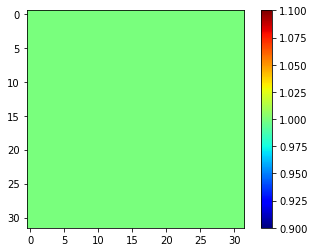

In [8]:
%matplotlib inline
slice_to_view = round(grid/2)
print(f"2D slice of {grid}x{grid}x{grid} grid microstructure:")
print(f"y = {slice_to_view}")
plt.imshow(microstructure[:,slice_to_view,:], cmap='jet', interpolation='nearest')
plt.colorbar()
plt.show()

## display volume fraction

In [8]:
cells_alpha =  (np.count_nonzero(microstructure >= 2))
cells_beta = (np.count_nonzero(microstructure == 1))
vol_fract_alpha = cells_alpha/(grid * grid * grid) * 100
vol_fract_beta = 100 - vol_fract_alpha

print('volume fraction alpha:', vol_fract_alpha)
print('volume fraction beta:', vol_fract_beta)

print('microstructures:', microstructure.max())

volume fraction alpha: 78.47900390625
volume fraction beta: 21.52099609375
microstructures: 6.0


## write .geom

In [9]:
# write out geom files
f = open('testing.geom', 'w')
f.write("\
5 header\n\
grid a %d b %d c %d\n\
size x %d.0 y %d.0 z %d.0\n\
origin x 0.0 y 0.0 z 0.0\n\
homogenization 1\n\
microstructures %d\n"\
%(grid,grid,grid,size,size,size,microstructure.max())
    )
np.savetxt(f, microstructure.reshape(grid*grid*grid),fmt='%d')
f.close()
print("Written testing.geom")

Written testing.geom


In [10]:
size = [1, 1, 1]
grid = [2, 2, 2]
microstructure = np.zeros((grid[0], grid[1], grid[2]))
print(microstructure)

g = Grid(microstructure, grid) # g is now geometry file
g.save(fname="test.vtr") # save g using new damask as .vtr

[[[0.00 0.00]
  [0.00 0.00]]

 [[0.00 0.00]
  [0.00 0.00]]]


## write material.yaml

In [11]:
print("beta quats in matfile:\n", beta_quats)

for n in range(0,n_laths):
    alphas_matfile = Quat.fromEulerAngles(phi1, PHI, phi2)
print("alpha quats in matfile:\n", alphas_matfile)

beta quats in matfile:
 [1.0000, -0.0000, -0.0000, -0.0000]
alpha quats in matfile:
 [0.0176, 0.9229, 0.0424, -0.3823]


In [12]:
# ===================== Write material.yaml ====================== #
# writing global material.yaml... #
material_yaml = open("material.yaml", 'w')
material_yaml.write("homogenization:\n\
  SX:\n\
    mech: {type: none}\n\
\n\
microstructure: # ============================================== \n")
# ------------- for each grain -------------- #
for grain in range(0, n_betagrains):
    material_yaml.write("\n# grain %d\n\
- constituents:\n\
  - fraction: 1.0\n\
    orientation: [%.16f, %.16f, %.16f, %.16f]\n\
    phase: Ti_beta\n\
  homogenization: SX\n"\
%(grain+1, beta_quats[0], beta_quats[1], beta_quats[2], beta_quats[3]))
    
for grain in range(0, n_laths):
    material_yaml.write("\n# grain %d\n\
- constituents:\n\
  - fraction: 1.0\n\
    orientation: [%.16f, %.16f, %.16f, %.16f]\n\
    phase: Ti_alpha\n\
  homogenization: SX\n"\
%(grain+1, alphas_matfile[0], alphas_matfile[1], alphas_matfile[2], alphas_matfile[3]))
# -------------------------------------------- #
material_yaml.write("\nphase: # ============================================== \n\
\n\
  Ti_alpha: # --------------------------\n\
    elasticity: {C_11: 160.0e9, C_12: 90.0e9, C_13: 66.0e9, C_33: 181.7e9, C_44: 46.5e9, type: hooke}\n\
    generic:\n\
      output: [F, Fe, Fp, P, Lp, O]\n\
    lattice: hex\n\
    c/a: 1.587\n\
    plasticity:\n\
      N_sl: [3, 3, 0, 6]\n\
      a_sl: 2.0\n\
      atol_xi: 1.0\n\
      dot_gamma_0_sl: 0.001\n\
      h_0_sl_sl: 15e6\n\
      h_sl_sl: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]\n\
      n_sl: 10\n\
      output: [gamma_sl, xi_sl]\n\
      xi_0_sl: [100e6, 100e6, 0.0, 200e6]\n\
      xi_inf_sl: [100e6, 100e6, 0.0, 200e6]\n\
      type: phenopowerlaw\n\
\n\
  Ti_beta: # --------------------------\n\
    elasticity: {C_11: 233.3e9, C_12: 135.5e9, C_44: 118.0e9, type: hooke}\n\
    generic:\n\
      output: [F, Fe, Fp, P, Lp, O]\n\
    lattice: bcc\n\
    plasticity:\n\
      N_sl: [12, 12]\n\
      a_sl: 2.0\n\
      atol_xi: 1.0\n\
      dot_gamma_0_sl: 0.001\n\
      h_0_sl_sl: 1000.0e6\n\
      h_sl_sl: [1, 1, 1.4, 1.4, 1.4, 1.4]\n\
      n_sl: 10\n\
      output: [gamma_sl, xi_sl]\n\
      xi_0_sl: [33.3e6, 33.3e6]\n\
      xi_inf_sl: [33.3e6, 33.3e6]\n\
      type: phenopowerlaw\n")
material_yaml.close()